In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 79.0 MB/s eta 0:00:00


In [ ]:
import zipfile
import os

# Paths to your zip files (update if different)
dataset_zip = "/content/drive/MyDrive/Crop Classification/Disease Classification 340x340.zip"
model_zip   = "/content/drive/MyDrive/Crop Classification/agri_y26s_cls_35_epochs.zip"

# Destination folders
dataset_root = "/content/Disease Classification 340x340"
model_folder = "/content/agri_y26s_cls_35_epochs"

# Unzip dataset
print("Unzipping dataset...")
with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
    zip_ref.extractall("/content")

# Unzip model
print("Unzipping model...")
with zipfile.ZipFile(model_zip, 'r') as zip_ref:
    zip_ref.extractall("/content")

# Verify they exist
print("Dataset folder exists:", os.path.exists(dataset_root))
print("Model folder exists:", os.path.exists(model_folder))

Unzipping dataset...
Unzipping model...
Dataset folder exists: True
Model folder exists: True


In [ ]:
from ultralytics import YOLO

# Load the best model
model = YOLO(f"{model_folder}/weights/best.pt")

# Show class names
class_names = model.names
print(f"Model expects {len(class_names)} classes:")
print(class_names)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Model expects 45 classes:
{0: 'Cabbage__Alternaria_Spot', 1: 'Cabbage__Black_Rot', 2: 'Cabbage__Downy_Mildew', 3: 'Cabbage__Healthy_Leaf', 4: 'Cauliflower__Alternaria_Disease', 5: 'Cauliflower__Bacterial_Soft_Rot', 6: 'Cauliflower__Bacterial_Spot', 7: 'Cauliflower__Black_Spot', 8: 'Cauliflower__Downy_Mildew', 9: 'Cauliflower__Healthy', 10: 'Cauliflower__Nutrient_Deficiency', 11: 'Chili__Bacterial_Spot', 12: 'Chili__Cercospora_Leaf_Spot', 13: 'Chili__Curl_Virus', 14: 'Chili__Healthy_Leaf', 15: 'Eggplant__Healthy_Leaf', 16: 'Eggplant__Insect_Pest_Disease', 17: 'Eggplant__Leaf_Spot_Disease', 18: 'Eggplant__Mosaic_Virus_Disease', 19: 'Eggplant__Wilt_Disease', 20: 'Gourd__Alternaria_Le

In [ ]:
# Run validation
val_results = model.val(
    data=dataset_root,          # path to dataset root (contains train/ and val/)
    imgsz=384,
    batch=32,
    workers=8,
    split='val',
)

# Access metrics correctly (object attributes)
print("\n" + "="*50)
print(f"Validation Top-1 Accuracy: {val_results.top1:.4f}")
print(f"Validation Top-5 Accuracy: {val_results.top5:.4f}")
print("="*50)

# You can also see the full metrics object:
# print(val_results)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s-cls summary (fused): 47 layers, 5,491,773 parameters, 0 gradients, 12.0 GFLOPs
train: /content/Disease Classification 340x340/train... found 13596 images in 45 classes ✅ 
val: /content/Disease Classification 340x340/val... found 1922 images in 45 classes ✅ 
test: /content/Disease Classification 340x340/test... found 1988 images in 45 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 497.9±211.5 MB/s, size: 9.1 KB)
val: Scanning /content/Disease Classification 340x340/val... 1922 images, 0 corrupt: 100% ━━━━━━━━━━━━ 1922/1922 4.7Kit/s 0.4s
val: New cache created: /content/Disease Classification 340x340/val.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 61/61 4.5it/s 13.4s
                   all      0.909      0.993
Speed: 0.3ms preprocess, 2.1ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val

Validation Top-1 Accura

In [ ]:
from ultralytics import YOLO

# Best model
best_model = YOLO(f"{model_folder}/weights/best.pt")
best_results = best_model.val(data=dataset_root, imgsz=384, batch=32, workers=8, split='val')
print(f"best.pt  -> Top-1: {best_results.top1:.4f}, Top-5: {best_results.top5:.4f}")

# Last model (epoch 35)
last_model = YOLO(f"{model_folder}/weights/last.pt")
last_results = last_model.val(data=dataset_root, imgsz=384, batch=32, workers=8, split='val')
print(f"last.pt  -> Top-1: {last_results.top1:.4f}, Top-5: {last_results.top5:.4f}")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s-cls summary (fused): 47 layers, 5,491,773 parameters, 0 gradients, 12.0 GFLOPs
train: /content/Disease Classification 340x340/train... found 13596 images in 45 classes ✅ 
val: /content/Disease Classification 340x340/val... found 1922 images in 45 classes ✅ 
test: /content/Disease Classification 340x340/test... found 1988 images in 45 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 527.0±162.7 MB/s, size: 9.1 KB)
val: Scanning /content/Disease Classification 340x340/val... 1922 images, 0 corrupt: 100% ━━━━━━━━━━━━ 1922/1922 732.9Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 61/61 4.2it/s 14.4s
                   all      0.909      0.993
Speed: 0.3ms preprocess, 1.7ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val2
best.pt  -> Top-1: 0.9095, Top-5: 0.9932
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128

In [ ]:
BATCH_SIZE = 32
LEARNING_RATE = 0.001
IMAGE_SIZE = 384
WORKERS = 8
SAVE_PERIOD = 10          # save checkpoint every 10 epochs
TOTAL_EPOCHS = 50         # 35 already done + 15 new

In [ ]:
import torch
ckpt = torch.load(f"{model_folder}/weights/last.pt", map_location=torch.device('cpu'), weights_only=False)
print("Last completed epoch:", ckpt['epoch'])

Last completed epoch: 34


In [ ]:
# Load the last checkpoint
last_model = YOLO(f"{model_folder}/weights/last.pt")

# Resume training
last_model.train(
    data=dataset_root,
    epochs=50,
    imgsz=384,
    batch=32,
    lr0=0.001,
    workers=8,
    save_period=10,
    resume=True,
    project=model_folder,
    name='.',
    exist_ok=True,
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/Disease Classification 340x340, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=384, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/agri_y26s_cls_35_epochs/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=G:\content\runs\classify\agri_y26s_cls_384, nbs=64, nms=False, opset=No

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c403e217170>
curves: []
curves_results: []
fitness: 0.9633194506168365
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.9334027171134949, 'metrics/accuracy_top5': 0.9932361841201782, 'fitness': 0.9633194506168365}
save_dir: PosixPath('/content/G:\\content\\runs\\classify\\agri_y26s_cls_384')
speed: {'preprocess': 0.18104968418369072, 'inference': 0.9068569620195224, 'loss': 0.004526007283908431, 'postprocess': 0.0013373210191875596}
task: 'classify'
top1: 0.9334027171134949
top5: 0.9932361841201782

In [ ]:
import pandas as pd

results_path = f"{model_folder}/results.csv"
df = pd.read_csv(results_path)
print(f"Total epochs recorded: {len(df)}")
print(df.tail(15))   # show last 15 rows (epochs 35–50)

Total epochs recorded: 23
    epoch      time  train/loss  metrics/accuracy_top1  metrics/accuracy_top5  \
8      21   4437.23     0.19152                0.92820                0.99792   
9      22   4916.00     0.17716                0.93392                0.99688   
10     23   5397.77     0.17053                0.93392                0.99272   
11     24   5878.16     0.14779                0.92508                0.99428   
12     25   6358.74     0.14908                0.93392                0.99584   
13     26   6839.42     0.13361                0.93288                0.99324   
14     27   7322.59     0.12378                0.93704                0.99688   
15     28   7807.48     0.10936                0.93444                0.99480   
16     29   8293.29     0.11510                0.93548                0.99428   
17     30   8777.56     0.10472                0.93809                0.99532   
18     31   9263.64     0.08633                0.94017                0.99532   
19

In [ ]:
import shutil

# Create a zip of the updated model folder
shutil.make_archive("/content/agri_y26s_cls_35_epochs_updated", 'zip', model_folder)

# Copy to Drive
!cp /content/agri_y26s_cls_35_epochs_updated.zip "/content/drive/MyDrive/Crop Classification/"

In [ ]:
!pip install ultralytics matplotlib seaborn scikit-learn pandas -q

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report
from ultralytics import YOLO
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Paths (adjust if different)
dataset_root = "/content/Disease Classification 340x340"
model_folder = "/content/agri_y26s_cls_35_epochs"   # or the updated folder after resuming
best_model_path = f"{model_folder}/weights/best.pt"
results_csv = f"{model_folder}/results.csv"

# Output folder for all generated files
output_dir = "/content/evaluation_results"
os.makedirs(output_dir, exist_ok=True)

# Load model
model = YOLO(best_model_path)
class_names = list(model.names.values())
num_classes = len(class_names)
print(f"Model loaded. Classes: {num_classes}")

Model loaded. Classes: 45


In [ ]:
# Run validation on test set
metrics = model.val(
    data=dataset_root,          # or path to data.yaml
    imgsz=384,
    batch=32,
    workers=8,
    split='test',                # change to 'val' if you prefer
)

# The ClassifyMetrics object does not have a 'class_result' attribute directly.
# Per-class accuracy is computed later using the confusion matrix from individual predictions.

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
train: /content/Disease Classification 340x340/train... found 13596 images in 45 classes ✅ 
val: /content/Disease Classification 340x340/val... found 1922 images in 45 classes ✅ 
test: /content/Disease Classification 340x340/test... found 1988 images in 45 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 237.2±59.4 MB/s, size: 9.1 KB)
test: Scanning /content/Disease Classification 340x340/test... 1988 images, 0 corrupt: 100% ━━━━━━━━━━━━ 1988/1988 347.4Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 63/63 4.0it/s 15.6s
                   all      0.897      0.995
Speed: 0.3ms preprocess, 1.8ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val5


In [ ]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class ImageFolderDataset(Dataset):
    def __init__(self, root, transform=None):
        self.root = Path(root)
        self.samples = []
        self.class_to_idx = {name: i for i, name in enumerate(class_names)}
        for class_folder in self.root.iterdir():
            if class_folder.is_dir() and class_folder.name in self.class_to_idx:
                label = self.class_to_idx[class_folder.name]
                for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG']:
                    for img_path in class_folder.glob(ext):
                        self.samples.append((img_path, label))
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label, str(img_path)   # also return path for sample display

transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
])

test_dataset = ImageFolderDataset(f"{dataset_root}/test", transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4)

all_preds = []
all_labels = []
all_paths = []

model.model.eval()
with torch.no_grad():
    for images, labels, paths in test_loader:
        images = images.to(model.device)
        outputs = model.model(images)
        outputs_tensor = outputs[0] # Access the first element of the tuple
        _, preds = torch.max(outputs_tensor, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_paths.extend(paths)

# Convert to numpy arrays
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)


In [ ]:
report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report.to_csv(f"{output_dir}/classification_report.csv")
print("Classification report saved.")

Classification report saved.


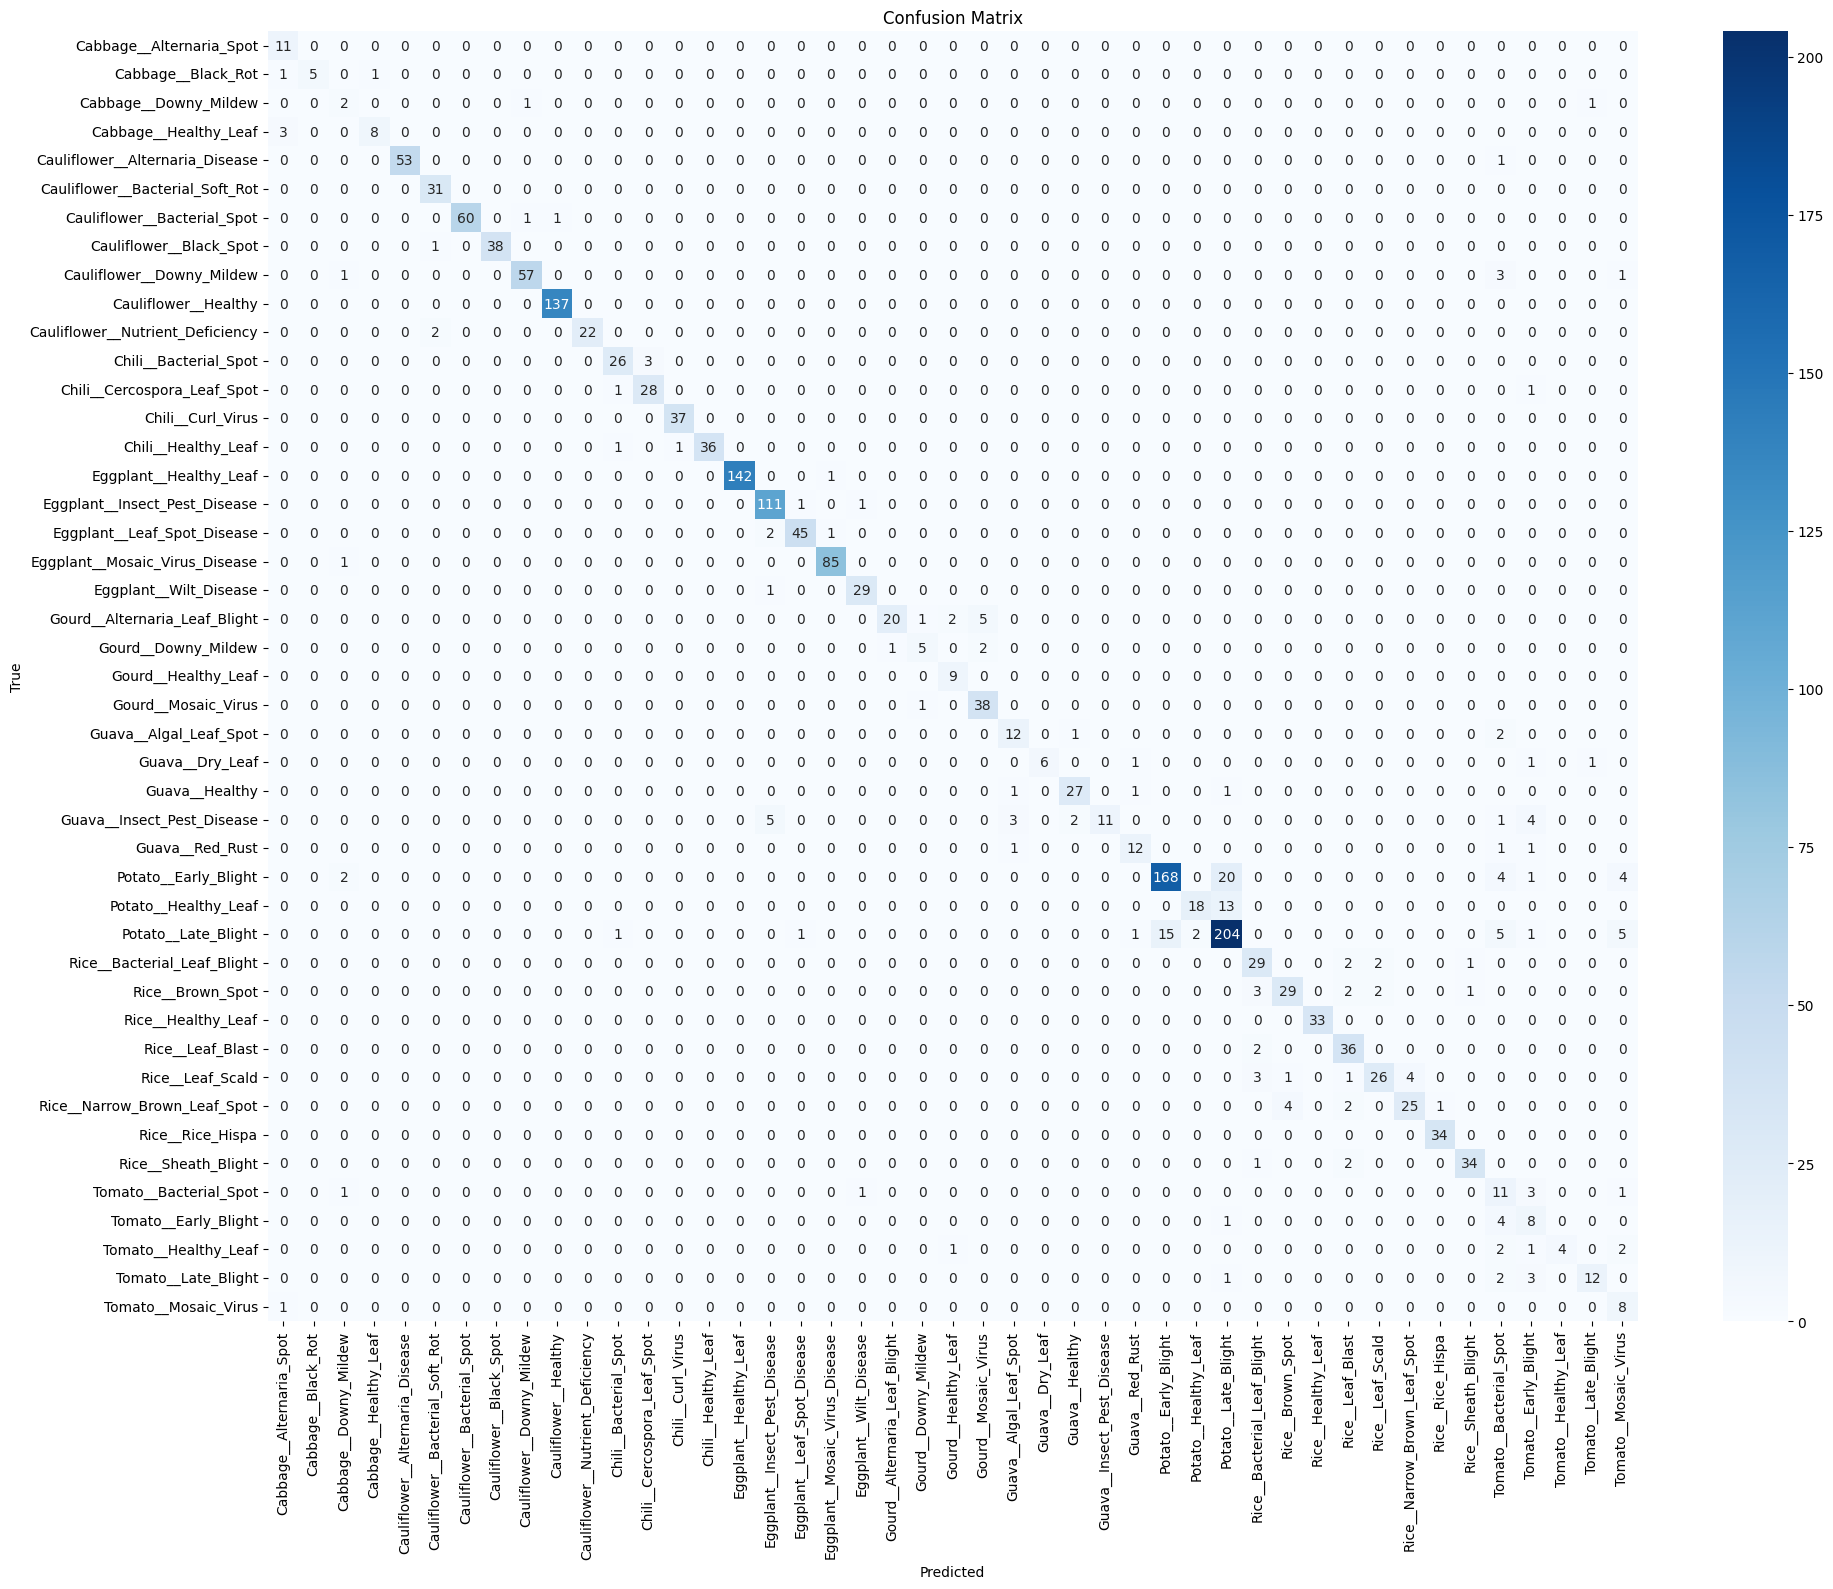

In [ ]:
plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig(f"{output_dir}/confusion_matrix.png", dpi=300)
plt.show()
plt.close()

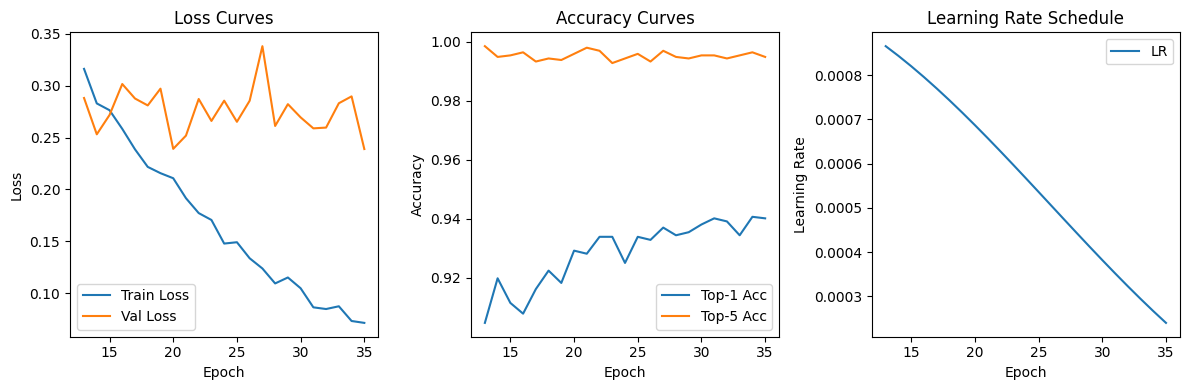

In [ ]:
if os.path.exists(results_csv):
    df = pd.read_csv(results_csv)

    # Plot loss
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.plot(df['epoch'], df['train/loss'], label='Train Loss')
    plt.plot(df['epoch'], df['val/loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss Curves')

    # Plot accuracy
    plt.subplot(1, 3, 2)
    plt.plot(df['epoch'], df['metrics/accuracy_top1'], label='Top-1 Acc')
    plt.plot(df['epoch'], df['metrics/accuracy_top5'], label='Top-5 Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy Curves')

    # Plot learning rate
    plt.subplot(1, 3, 3)
    plt.plot(df['epoch'], df['lr/pg0'], label='LR')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.legend()
    plt.title('Learning Rate Schedule')

    plt.tight_layout()
    plt.savefig(f"{output_dir}/training_curves.png", dpi=300)
    plt.show()
    plt.close()
else:
    print("results.csv not found, skipping training curves.")

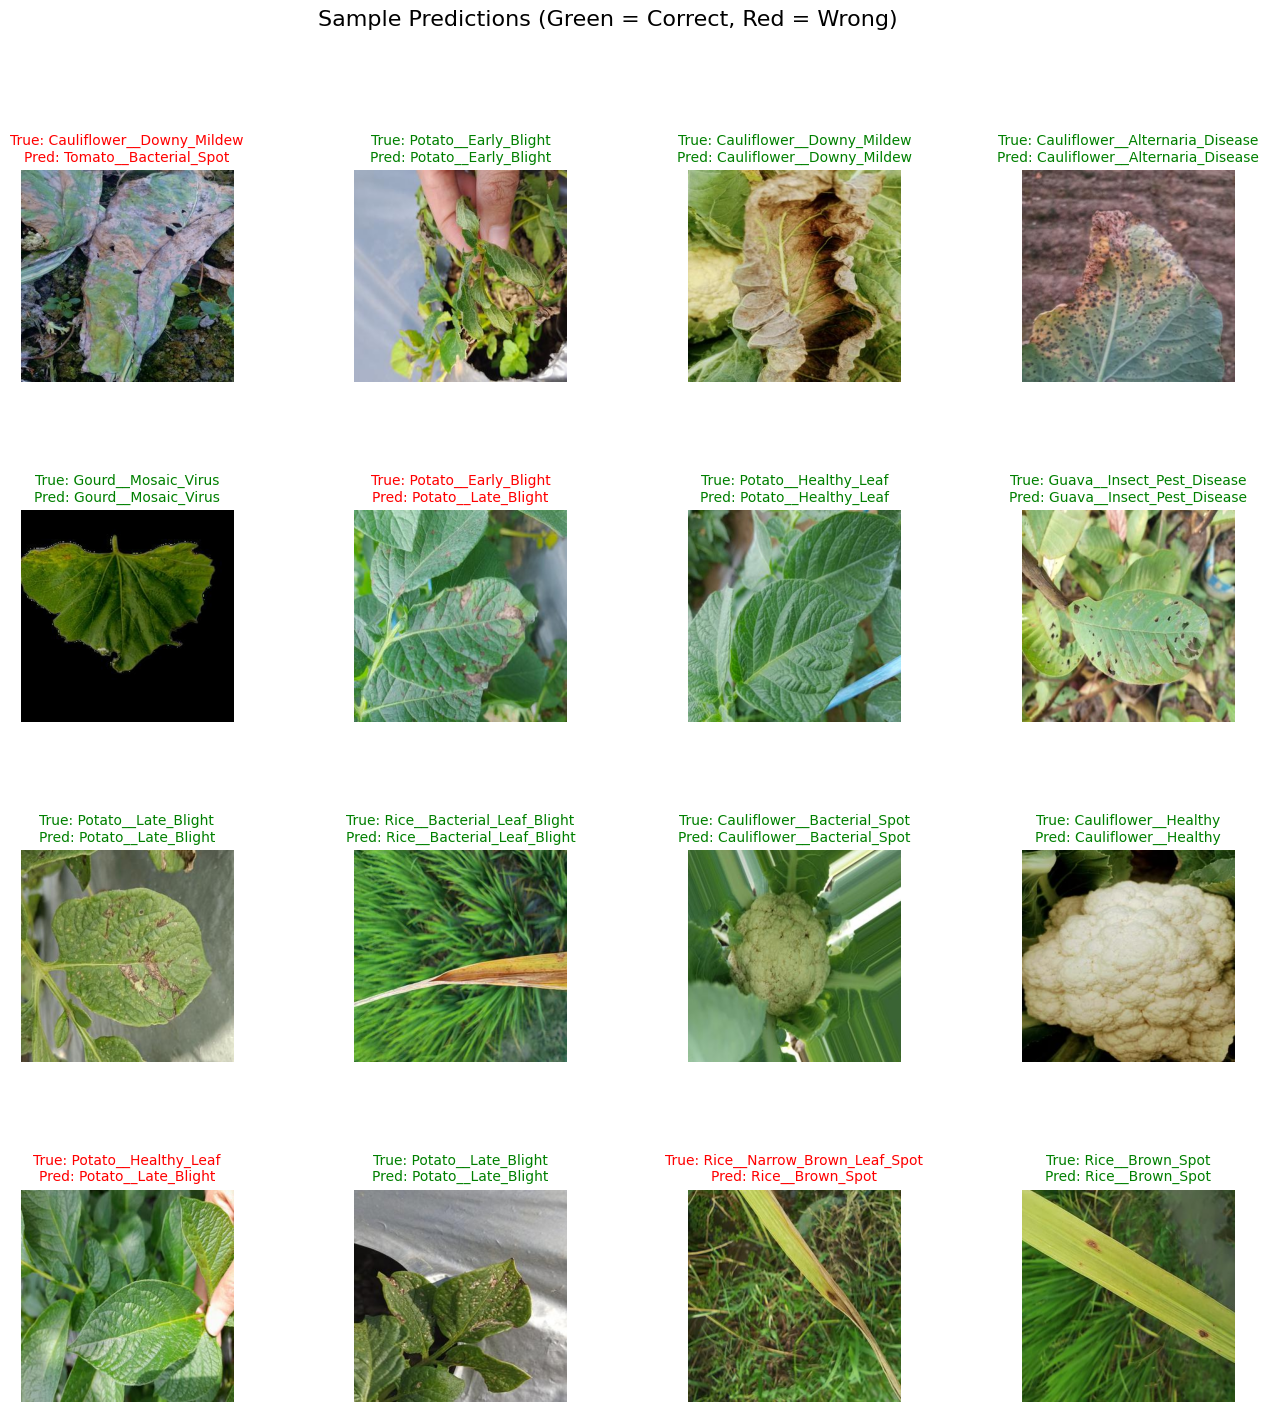

In [ ]:
import matplotlib.gridspec as gridspec
import random

# Choose 16 random indices
num_samples = 16
indices = random.sample(range(len(all_paths)), num_samples)

fig = plt.figure(figsize=(16, 16))
gs = gridspec.GridSpec(4, 4, wspace=0.4, hspace=0.6)

for i, idx in enumerate(indices):
    ax = plt.subplot(gs[i])
    img_path = all_paths[idx]
    img = Image.open(img_path)
    ax.imshow(img)
    true_label = class_names[all_labels[idx]]
    pred_label = class_names[all_preds[idx]]
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=10)
    ax.axis('off')

plt.suptitle('Sample Predictions (Green = Correct, Red = Wrong)', fontsize=16)
plt.savefig(f"{output_dir}/sample_predictions.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [ ]:
# Compute per-class accuracy
class_correct = np.zeros(num_classes)
class_total = np.zeros(num_classes)
for t, p in zip(all_labels, all_preds):
    class_total[t] += 1
    if t == p:
        class_correct[t] += 1

class_acc = class_correct / (class_total + 1e-10)
df_class_acc = pd.DataFrame({
    'class': class_names,
    'total_images': class_total,
    'correct': class_correct,
    'accuracy': class_acc
})
df_class_acc.to_csv(f"{output_dir}/per_class_accuracy.csv", index=False)

# Also save overall metrics
overall_acc = (all_preds == all_labels).mean()
overall_top5 = metrics.top5 # we can compute top-5 if needed
# For top-5, we need probabilities, we can compute from model output if we rerun with probs
# But we already have top-5 from validation metrics object
with open(f"{output_dir}/overall_metrics.txt", 'w') as f:
    f.write(f"Overall Top-1 Accuracy: {metrics.top1:.4f}\n")
    f.write(f"Overall Top-5 Accuracy: {metrics.top5:.4f}\n")
    f.write(f"Test set size: {len(all_labels)}\n")

In [ ]:
import shutil
from google.colab import files

shutil.make_archive("/content/evaluation_results", 'zip', output_dir)
print("Zip created: /content/evaluation_results.zip")

# Download to local machine
files.download("/content/evaluation_results.zip")